# Name: Fereshteh Sadeghi Naieni Fard

# PART II: Data Pre-Processing

## 1. Load Data

#### 1.1. Import Libraries and Modules

In [160]:
#Import python libraries: Numpy and Pandas
import pandas as pd
import numpy as np

#Import libraries and modules of data visualization
import seaborn as sns
from pandas.plotting import scatter_matrix
from matplotlib import pyplot

#### 1.2. Load data

#### Main Feature of the studied dataset   
The dataset, sheltered_animals.csv, has 10 attributes as follows:  
Animal ID: All animals receive a unique Animal ID during intake.  
DateTime: Date and time when the outcome occurred   
MonthYear: Same as DateTime of Outcome.  
DateOfBirth: Birthdate of the animal.  
AnimalType: Animal species.   
SexUponOutcome: Sex of the animal when it left the shelter and whether or not it was spayed or neutered.   
AgUponOutcome: Age of the animal when it left the shelter.   
Breed: Breed of the animal.   
Color: Color of the animal.   
OutcomeType: What was the outcome of the animal when it left the shelter.   

In [161]:
#Specify the data file and where it is
filename='C:/unt courses/Ph.D courses/INFO-ADTA 5340-Discovery and Learning with Big Data/Week8 Final Project/sheltered_animals.csv'

#Specify the fields names
names=['Animal ID','DateTime','MonthYear','DateOfBirth','AnimalType','SexUponOutcome','AgUponOutcome','Breed','Color','OutcomeType']

#Load the data into a pandas data frame
df=pd.read_csv(filename, names=names)


## 2. Data Preprocessing

#### 2.1. Handling Missing Values

In [162]:
#Replace Zeros with Nan to treat them as missing
df = df.replace('0', np.nan)

In [163]:
#Print number of null values in each field
print(df.isnull().sum())

Animal ID         0
DateTime          0
MonthYear         0
DateOfBirth       0
AnimalType        0
SexUponOutcome    2
AgUponOutcome     4
Breed             0
Color             0
OutcomeType       7
dtype: int64


In [164]:
#Removing all null values from the current fields
df=df.dropna()

In [165]:
#print 5 first columns of the dataset
print(df.head())

  Animal ID          DateTime         MonthYear DateOfBirth AnimalType  \
0   A771830  12/27/2018 13:25  12/27/2018 13:25   5/10/2017        Dog   
1   A779576   10/1/2018 17:03   10/1/2018 17:03   4/18/2018        Cat   
2   A741715   1/11/2017 18:17   1/11/2017 18:17    3/7/2016        Cat   
3   A658751  11/13/2016 13:38  11/13/2016 13:38   7/14/2011        Dog   
4   A721285   2/24/2016 14:42   2/24/2016 14:42   2/24/2014      Other   

  SexUponOutcome AgUponOutcome                   Breed        Color  \
0  Neutered Male        1 year            Pit Bull Mix   White/Blue   
1  Neutered Male      5 months  Domestic Shorthair Mix  Brown Tabby   
2  Spayed Female     10 months  Domestic Shorthair Mix       Calico   
3  Neutered Male       5 years      Border Terrier Mix          Tan   
4        Unknown       2 years             Raccoon Mix   Black/Gray   

       OutcomeType  
0         Adoption  
1         Adoption  
2         Adoption  
3  Return to Owner  
4       Euthanasia  


#### 2.2 Decide on which columns should be remained in the final Dataset: This Section was created for just making decision

##### 2.2.1. Converting datatime columns to numeric

##### Description
This code converts date columns from text format into numerical values that can be used for correlation. First, each column listed in date_cols is transformed into a proper datetime object using pd.to_datetime(), which interprets strings such as “12/20/2017” as real calendar dates. After the conversion, the datetime values are turned into integers using .astype('int64'), which represents each date as the number of nanoseconds since January 1, 1970. Because nanoseconds are too large to work with in most analyses, the code divides these numbers by (10^9) to convert them into seconds. This results in a clean numeric timestamp for each date, making the variables compatible with correlation calculations that require numeric inputs rather than textual or datetime formats.

In [166]:
# To remain the main dataset untouched create a copy from it
df1=df
#Animal Id does not need to go through decison making process. So it removed from the datadrame in the first step
df1 = df1.drop(columns=['Animal ID'])

# Create a substet of variables include all dates
date_cols = ["DateTime", "MonthYear", "DateOfBirth"]  

# convert to numeric seconds
for col in date_cols:
    df1[col] = pd.to_datetime(df[col], errors='coerce')
    df1[col] = df1[col].astype('int64') // 10**9  

##### Description
Here we convert the text-based age field (AgUponOutcome) into a single numeric value shows age in months, which makes the data usable for statistical analysis and machine-learning models. The code first splits the original age string—such as "2 years" into two parts: the numeric value (age_value) and the time unit (period). It then processes each row to convert these units into a consistent measurement. To do this, the code normalizes plural words (e.g., “years,” “months”) by removing the trailing “s” and then applies a conversion rule: years are multiplied by 12, months remain unchanged, weeks are divided by 4, and days are divided by 30. This produces an age expressed uniformly in months, which is appended to a list. After the loop completes, the list of converted month values replaces the original AgUponOutcome column. Finally, the helper columns age_value and period—which were temporarily created for the conversion removed to keep the dataset clean and ready for analysis.

In [167]:
#Extract the numer and the period title from the field AgUponOutcome for further calculations
df1[['age_value', 'period']] = df1['AgUponOutcome'].str.split(' ', expand=True)    
#Transform each value to a number that represents the number of months  
month_list=[]
for i in range(len(df1)):
    unit=''
    age=0
    unit=str(df1.iloc[i]['period']).lower()
    age=float(df1.iloc[i]['age_value'])
    if(unit.endswith('s')):
        unit=unit[:-1]
    if unit=='year':
        age=age*12
    if unit=='month':
        age=age
    if unit=='week':
        age=age/4
    if unit=='day':
        age=age/30
    month_list.append(age)
    
df1['AgUponOutcome']=month_list

#Drop two additional fields including age_value and age_value which were generated in advance
df1 = df1.drop(columns=['age_value'])
df1 = df1.drop(columns=['period'])


In [168]:
# Print the data types of all columns to see which columns are still in text format
print(df1.dtypes)

DateTime            int64
MonthYear           int64
DateOfBirth         int64
AnimalType         object
SexUponOutcome     object
AgUponOutcome     float64
Breed              object
Color              object
OutcomeType        object
dtype: object


##### Description
Here we converted all remaining categorical (text) variables in the dataset into numeric codes, which is necessary for correlation analysis. In more detail, the code loops through every column in the dataframe and checks whether the column’s data type is object. For each such column, it applies pd.factorize(), a method that replaces each unique category with an integer code. For example, a column like "AnimalType" containing values such as "Dog", "Cat", and "Other" would be transformed into numeric labels like 0, 1, and 2. By storing the first element of the factorization output, the code replaces the text column directly with its numeric version, allow all columns in the dataframe to become fully numeric and therefore suitable for further statistical or correlation computations.

In [169]:
# Factorize (numeric encode) all remaining categorical columns
for col in df1.columns:
    if df1[col].dtype == object:
        df1[col] = pd.factorize(df1[col])[0]


##### Description
This code block generates a lower-triangle heatmap that visualizes the Pearson correlation among several key variables in the dataset, including the target variable OutcomeType. The process begins by explicitly defining the list of columns to be included in the correlation analysis to make fields appear in a consistent order. Using this list, a new dataframe is created that contains them. Next, the code computes the Pearson correlation matrix using NumPy’s corrcoef function, which requires the data to be in numeric format. The resulting matrix is then converted into a pandas DataFrame so that row and column labels correspond to the variable names, making interpretation easier.
To create a clean and non-redundant visual representation, the code constructs a mask that hides the upper triangle of the correlation matrix, including the diagonal. This is done because the matrix is symmetric, and showing both halves would duplicate information. Finally, a heatmap is generated using seaborn, with annotations displaying the numeric correlation values and a color gradient indicating the strength and direction of relationships. Finally we used matplotlib to visualize the correlation matrix.

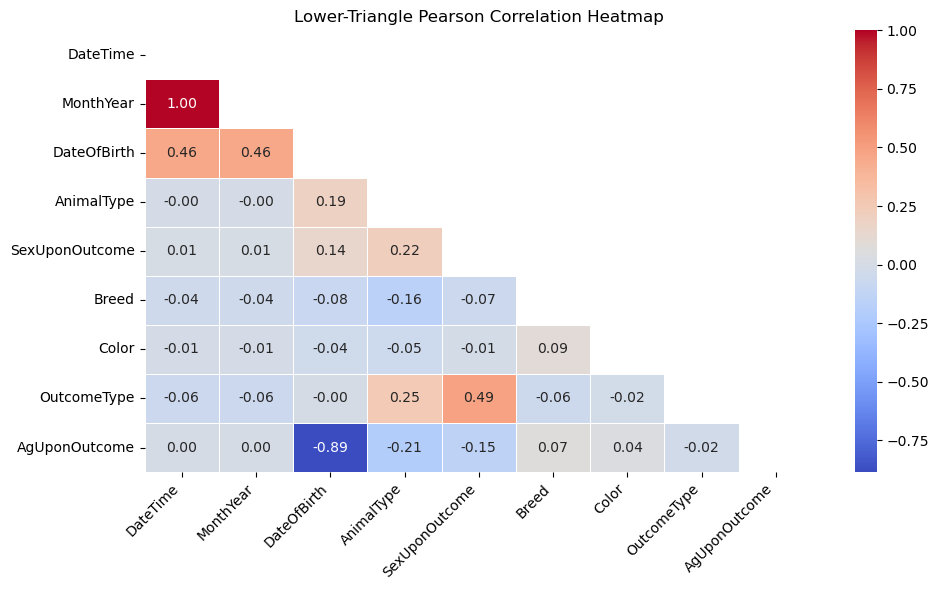

In [171]:

# 1. Make sure df1 has all these columns
cols = [
    "DateTime",
    "MonthYear",
    "DateOfBirth",
    "AnimalType",
    "SexUponOutcome",
    "Breed",
    "Color",
    "OutcomeType",
    "AgUponOutcome",   # <-- include it here
]

df_corr = df1[cols]

# 2. Pearson correlation matrix (NumPy)
data = df_corr.values.astype(float)
corr_matrix = np.corrcoef(data, rowvar=False)

corr_df = pd.DataFrame(corr_matrix, index=cols, columns=cols)

# 3. Lower-triangle mask
mask = np.triu(np.ones_like(corr_df, dtype=bool))

# 4. Plot
pyplot.figure(figsize=(10, 6))
sns.heatmap(
    corr_df,
    mask=mask,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    square=False,
    cbar=True
)

pyplot.title("Lower-Triangle Pearson Correlation Heatmap")
pyplot.xticks(rotation=45, ha="right")
pyplot.yticks(rotation=0)
pyplot.tight_layout()
pyplot.show()


##### Description
According to the results created for correlation matrix the fields that have meaningful correlation is SexUponOutcome which as measure more than 0.3. However, in this study we include all the variables with correlation more than zero that includes Datetime, animal type, sex upon outcome, breed and color. Another important note that should be added here is that Datetime and monthyear show similar values. Also Datetime is a field that present the date and time of the outcome. So its correlation doesn not mean its causality. Therefor for further analysis and extracting final dataset, we exploded this field as well.

#### 2.3. Exclusion of unnecessary fields and Transform the data of the attribute “Age upon outcome” from text to numeric   
 

In [173]:
#Excluded uninfluencial fields for predition of outcome type
df = df.drop(columns=['Animal ID', 'DateTime', 'DateOfBirth', 'MonthYear'])

In [174]:
#Transform the data of the attribute “Age upon outcome” from text to numeric
#Extract the number and the period  from the field AgUponOutcome for further calculations
df[['age_value', 'period']] = df['AgUponOutcome'].str.split(' ', expand=True)    
#Transform each value to a number that represents the number of months  
month_list=[]
for i in range(len(df)):
    unit=''
    age=0
    unit=str(df.iloc[i]['period']).lower()
    age=float(df.iloc[i]['age_value'])
    if(unit.endswith('s')):
        unit=unit[:-1]
    if unit=='year':
        age=age*12
    if unit=='month':
        age=age
    if unit=='week':
        age=age/4
    if unit=='day':
        age=age/30
    month_list.append(age)
    
df['AgUponOutcome']=month_list

#Drop two additional fields including age_value and age_value which were generated in advance
df = df.drop(columns=['age_value'])
df = df.drop(columns=['period'])

In [175]:
#print 5 first columns of the dataset
print(df.head())

  AnimalType SexUponOutcome  AgUponOutcome                   Breed  \
0        Dog  Neutered Male           12.0            Pit Bull Mix   
1        Cat  Neutered Male            5.0  Domestic Shorthair Mix   
2        Cat  Spayed Female           10.0  Domestic Shorthair Mix   
3        Dog  Neutered Male           60.0      Border Terrier Mix   
4      Other        Unknown           24.0             Raccoon Mix   

         Color      OutcomeType  
0   White/Blue         Adoption  
1  Brown Tabby         Adoption  
2       Calico         Adoption  
3          Tan  Return to Owner  
4   Black/Gray       Euthanasia  


##### 2.4. Extract the Final Preprocessed Dataset to a CSV file

In [176]:
df.to_csv('C:/unt courses/Ph.D courses/INFO-ADTA 5340-Discovery and Learning with Big Data/Week8 Final Project/sheltered_animals_clean.csv',index=False)